# Cohort creation Notebook

## Dependencies and Setup

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn

In [2]:
user = "postgres"
password = "mimic"
host = "localhost"   
port = "5432"
database = "mimiciv"

In [3]:
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")


# Load data 


## main cohort

In [8]:
df_resp_inf_icu_final = pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/df_resp_inf_icu_final.parq", engine="fastparquet")
df_resp_inf_icu_hadm_ids = tuple(df_resp_inf_icu_final.hadm_id.unique().tolist())

In [5]:
query = """
SELECT 
    COUNT(*) AS icu_stays,
    COUNT(DISTINCT hadm_id) AS icu_admissions,
    COUNT(DISTINCT subject_id) AS unique_patients
FROM mimiciv_icu.icustays;
"""

df_counts = pd.read_sql_query(sql=query, con=engine)
print(df_counts)

   icu_stays  icu_admissions  unique_patients
0      94458           85242            65366


In [ ]:
# query=f"""SELECT 
#     p.subject_id,
#     p.gender,
#     p.anchor_age,
#     p.anchor_year,
#     a.hadm_id,
#     a.admittime AS hospital_admit_time,
#     a.dischtime AS hospital_discharge_time,
#     a.deathtime AS hospital_death_time,
#     i.stay_id,
#     i.intime AS icu_admit_time,
#     i.outtime AS icu_discharge_time,
#     i.los AS icu_los_days,
#     a.admission_type,
#     a.admission_location,
#     a.discharge_location,
#     a.race
# FROM mimiciv_hosp.patients p
# JOIN mimiciv_hosp.admissions a
#   ON p.subject_id = a.subject_id
# LEFT JOIN mimiciv_icu.icustays i
#   ON a.hadm_id = i.hadm_id
#  where 
#  a.hadm_id IS NOT NULL 
# AND a.hadm_id in {df_resp_inf_icu_hadm_ids};  """

# df_admissions = pd.read_sql_query(sql=query, con=engine)

In [ ]:
# df_admissions.to_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/df_admissions.parq", engine="fastparquet")

NameError: name 'df_admissions' is not defined

In [ ]:
df_admissions = pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic/MIMIC/model_building/outputs/df_admissions.parq", engine="fastparquet")    
hh.dxx(df_admissions)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,3620 | 12818,16438 | 0,16438 | 0,16429 | 9,16429 | 9,16438 | 0,16438 | 0,16405 | 33,16438 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN


In [15]:
rep_inf_cohort= df_admissions.merge(df_resp_inf_icu_final, on=["hadm_id", "subject_id","stay_id"], how="inner")
hh.dxx(rep_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


<Axes: >

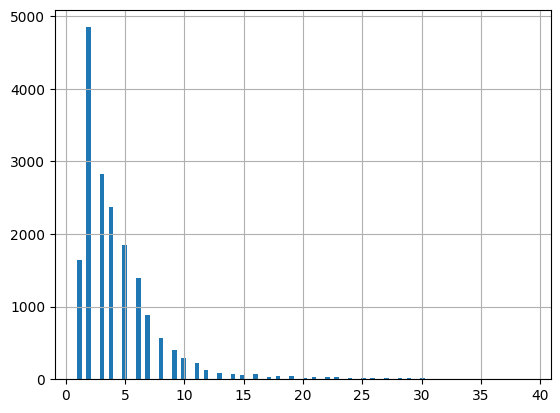

In [18]:
df_resp_inf_icu_final.seq_num.hist(bins=100)

In [19]:
hh.parq(rep_inf_cohort, 'resp_inf_cohort_')

File saved at: resp_inf_cohort_23Jan26_1953.parquet


In [20]:
resp_inf_cohort= hh.load_data('./parq/resp_inf_cohort_23Jan26_1953.parquet')
hh.dxx(resp_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


Demographics

In [ ]:
resp_inf_cohort.race.value_counts()

race
WHITE                                        10793
BLACK/AFRICAN AMERICAN                        1867
UNKNOWN                                       1760
OTHER                                          566
WHITE - OTHER EUROPEAN                         447
UNABLE TO OBTAIN                               376
HISPANIC/LATINO - PUERTO RICAN                 287
WHITE - RUSSIAN                                241
ASIAN - CHINESE                                235
ASIAN                                          214
BLACK/CAPE VERDEAN                             156
BLACK/CARIBBEAN ISLAND                         143
HISPANIC/LATINO - DOMINICAN                    141
PORTUGUESE                                     110
HISPANIC OR LATINO                             103
BLACK/AFRICAN                                   94
ASIAN - SOUTH EAST ASIAN                        93
PATIENT DECLINED TO ANSWER                      63
HISPANIC/LATINO - GUATEMALAN                    58
WHITE - EASTERN EUROPEAN  

In [25]:
resp_inf_cohort.admission_type.value_counts()


admission_type
EW EMER.                       10352
URGENT                          3475
OBSERVATION ADMIT               2868
DIRECT EMER.                     604
SURGICAL SAME DAY ADMISSION      596
ELECTIVE                         190
EU OBSERVATION                    16
DIRECT OBSERVATION                 7
AMBULATORY OBSERVATION             1
Name: count, dtype: int64

## lab test data

In [33]:
resp_lab_test_icu_df=pd.read_parquet("parq/resp_lab_test_icu_inf_df.parq")
hh.dxx(resp_lab_test_icu_df)


11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
ICU Stay ID column not found.
10.9M Rows, shape: (10886372, 18)



,subject_id,hadm_id,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10886372 | 0,10846170 | 40202,10287991 | 598381,9895023 | 991349,9352168 | 1534204,8869937 | 2016435,8869937 | 2016435,4497708 | 6388664,9083523 | 1802849,1632399 | 9253973
nunique,11864,13549,10886372,1158463,848,688,9,3,682239,1601059,15045,18070,57,118,170,2,3,5100
0,10001843,26133978,17043,80784905,50861,Alanine Aminotransferase (ALT),Blood,Chemistry,2134-12-05 09:08:00,2134-12-05 10:13:00,77,77.000000,IU/L,0.000000,40.000000,abnormal,STAT,None
1,10001843,26133978,17044,80784905,50862,Albumin,Blood,Chemistry,2134-12-05 09:08:00,2134-12-05 10:13:00,2.4,2.400000,g/dL,3.500000,5.200000,abnormal,STAT,None
2,10001843,26133978,17045,80784905,50863,Alkaline Phosphatase,Blood,Chemistry,2134-12-05 09:08:00,2134-12-05 10:13:00,569,569.000000,IU/L,40.000000,130.000000,abnormal,STAT,None


In [34]:
resp_lab_test_icu_df.columns

Index(['subject_id', 'hadm_id', 'labevent_id', 'specimen_id', 'itemid',
       'label', 'fluid', 'category', 'charttime', 'storetime', 'value',
       'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag',
       'priority', 'comments'],
      dtype='object')

In [38]:
icu_lab_tests= (pd.read_parquet('./parq/lab_test_icu_df.parq'))
hh.dxx(icu_lab_tests)

11.8k Unique Patient IDs (11782)
13.4k Unique Admission IDs (13443)
16.1k Unique ICU Stay IDs (16133)
6.9M Rows, shape: (6867008, 24)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6867008 | 0,6843544 | 23464,6544501 | 322507,6205278 | 661730,5833872 | 1033136,5459869 | 1407139,5459869 | 1407139,2852209 | 4014799,5192206 | 1674802,1079921 | 5787087
nunique,11782,13443,16133,14,14,16133,16133,15951,6867008,760903,828,676,9,3,481148,1106584,12708,15329,57,114,165,2,3,4112
0,10001843,26133978,39698942,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,17153,44776621,50802,Base Excess,Blood,Blood Gas,2134-12-05 19:30:00,2134-12-05 19:52:00,1,1.000000,mEq/L,nan,nan,None,None,None
1,10008924,23676183,30244392,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2139-07-09 23:42:19,2139-07-11 17:04:07,1.723472,143897,42163508,50861,Alanine Aminotransferase (ALT),Blood,Chemistry,2139-07-10 05:20:00,2139-07-10 06:36:00,68,68.000000,IU/L,0.000000,40.000000,abnormal,ROUTINE,None
2,10008924,23676183,30244392,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2139-07-09 23:42:19,2139-07-11 17:04:07,1.723472,143898,42163508,50862,Albumin,Blood,Chemistry,2139-07-10 05:20:00,2139-07-10 06:36:00,3.8,3.800000,g/dL,3.500000,5.200000,None,ROUTINE,None


In [39]:
icu_lab_tests.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'labevent_id', 'specimen_id', 'itemid',
       'label', 'fluid', 'category', 'charttime', 'storetime', 'value',
       'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag',
       'priority', 'comments'],
      dtype='object')

## microbiology

In [40]:
resp_micro_hosp_icu_inf_df=hh.load_data('./parq/resp_micro_hosp_icu_inf_df_23Jan26_2050.parquet')
hh.dxx(resp_micro_hosp_icu_inf_df)


11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 18)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object
NotNA | NA,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,156805 | 264934,127899 | 293840,127899 | 293840,121517 | 300222,356177 | 65562
nunique,11348,12922,15723,14,14,15723,15723,15561,289021,28540,121843,72,128,312,47,6,26,264
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5128,2133-09-17 00:00:00,2133-09-17 13:05:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5139,2133-10-01 00:00:00,2133-10-01 23:17:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.


In [27]:

resp_micro_icu_inf_df = hh.load_data('./parq/resp_micro_icu_inf_df.parquet') # has all micro records

hh.dxx(resp_micro_icu_inf_df)

10.7k Unique Patient IDs (10722)
12.2k Unique Admission IDs (12150)
13.9k Unique ICU Stay IDs (13891)
205.8k Rows, shape: (205772, 18)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object
NotNA | NA,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,205772 | 0,78991 | 126781,63461 | 142311,63461 | 142311,60506 | 145266,181592 | 24180
nunique,10722,12150,13891,14,14,13891,13891,13762,205772,24096,81670,68,122,273,45,6,26,260
0,10013310,22098926,32769810,Neuro Intermediate,Neuro Intermediate,2153-06-10 11:55:42,2153-06-16 19:03:14,6.296898,5560,2153-06-10 00:00:00,2153-06-10 17:45:00,URINE,URINE CULTURE,None,None,None,nan,NO GROWTH.
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2603,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,FLUID CULTURE,None,None,None,nan,NO GROWTH.


In [28]:
resp_micro_icu_inf_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'microevent_id', 'chartdate', 'charttime',
       'spec_type_desc', 'test_name', 'org_name', 'ab_name', 'interpretation',
       'dilution_value', 'comments'],
      dtype='object')

In [11]:
resp_micro_icu_inf_df.groupby('last_careunit').hadm_id.nunique()


last_careunit
Cardiac Vascular Intensive Care Unit (CVICU)         740
Coronary Care Unit (CCU)                            1341
Intensive Care Unit (ICU)                             18
Medical Intensive Care Unit (MICU)                  4468
Medical/Surgical Intensive Care Unit (MICU/SICU)    3127
Medicine                                              13
Neuro Intermediate                                   233
Neuro Stepdown                                        64
Neuro Surgical Intensive Care Unit (Neuro SICU)      213
PACU                                                  15
Surgery/Trauma                                         8
Surgery/Vascular/Intermediate                        120
Surgical Intensive Care Unit (SICU)                 1331
Trauma SICU (TSICU)                                 1137
Name: hadm_id, dtype: int64

In [12]:
resp_micro_icu_inf_df.groupby('first_careunit').hadm_id.nunique()

first_careunit
Cardiac Vascular Intensive Care Unit (CVICU)         740
Coronary Care Unit (CCU)                            1341
Intensive Care Unit (ICU)                             18
Medical Intensive Care Unit (MICU)                  4468
Medical/Surgical Intensive Care Unit (MICU/SICU)    3127
Medicine                                              13
Neuro Intermediate                                   233
Neuro Stepdown                                        64
Neuro Surgical Intensive Care Unit (Neuro SICU)      213
PACU                                                  15
Surgery/Trauma                                         8
Surgery/Vascular/Intermediate                        120
Surgical Intensive Care Unit (SICU)                 1331
Trauma SICU (TSICU)                                 1137
Name: hadm_id, dtype: int64

## ast results in micro data

In [9]:
resp_ast_icu_inf_df=pd.read_parquet("resp_ast_icu_inf_df.parquet", engine="fastparquet") # has micro records with ast results
hh.dxx(resp_ast_icu_inf_df)

3.2k Unique Patient IDs (3241)
3.5k Unique Admission IDs (3501)
3.7k Unique ICU Stay IDs (3698)
63.5k Rows, shape: (63461, 12)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,63461 | 0,63461 | 0,63461 | 0,63461 | 0,63461 | 0,63461 | 0,63461 | 0,63461 | 0,63461 | 0,60506 | 2955,63461 | 0,46789 | 16672
nunique,3241,3501,3698,14,6237,32,14,115,44,26,5,46
0,10004401,28128182,37919158,Medical Intensive Care Unit (MICU),2144-02-12 21:42:00,SPUTUM,RESPIRATORY CULTURE,STAPH AUREUS COAG +,ERYTHROMYCIN,8.000000,R,SPARSE GROWTH Commensal Respiratory Flora.
1,10014702,23586319,33494873,Coronary Care Unit (CCU),2173-07-04 09:11:00,SPUTUM,RESPIRATORY CULTURE,STAPH AUREUS COAG +,ERYTHROMYCIN,8.000000,R,SPARSE GROWTH Commensal Respiratory Flora.
2,10014702,23586319,33494873,Coronary Care Unit (CCU),2173-07-04 09:11:00,SPUTUM,RESPIRATORY CULTURE,STAPH AUREUS COAG +,CLINDAMYCIN,8.000000,R,SPARSE GROWTH Commensal Respiratory Flora.


## prescribtions  

In [10]:
resp_pres_icu_inf_results_df=pd.read_parquet("resp_pres_icu_inf_results_df.parquet", engine="fastparquet")
hh.dxx(resp_pres_icu_inf_results_df)

11.9k Unique Patient IDs (11869)
13.6k Unique Admission IDs (13568)
16.4k Unique ICU Stay IDs (16378)
1.5M Rows, shape: (1545202, 23)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,float64,object
NotNA | NA,1545202 | 0,1545202 | 0,1545202 | 0,1545202 | 0,1545202 | 0,1545202 | 0,1543468 | 1734,1545202 | 0,1545202 | 0,1543558 | 1644,1545202 | 0,1545202 | 0,1544627 | 575,1275905 | 269297,1543316 | 1886,1543873 | 1329,344500 | 1200702,1543879 | 1323,1543879 | 1323,1543879 | 1323,1543878 | 1324,857455 | 687747,1543919 | 1283
nunique,11869,13568,16378,14,14,16378,16370,1157125,372585,320270,3,2660,2777,2434,4759,2146,41,1295,88,1610,73,13,81
0,10002428,28662225,33987268,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-12 16:24:18,2156-04-17 15:57:08,584485,2156-04-14 15:00:00,2156-04-15 14:00:00,BASE,Lactated Ringers,LR1000,001187,00338011704,1000ml Bag,None,1000,mL,1,BAG,nan,IV
1,10002428,28662225,38875437,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-19 18:11:19,2156-04-26 18:58:41,3539134,2156-04-25 23:00:00,2156-04-26 19:00:00,MAIN,Furosemide,FURO20I,008205,00517570225,20mg/2mL Vial,None,10,mg,0.5,VIAL,1.000000,IV
2,10002428,28662225,33987268,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2156-04-12 16:24:18,2156-04-17 15:57:08,3780650,2156-04-14 01:00:00,2156-04-15 00:00:00,BASE,Lactated Ringers,LR1000,001187,00338011704,1000ml Bag,None,1000,mL,1,BAG,nan,IV


## medication administration records EMAR

In [11]:
resp_emar_icu_inf_results_df=pd.read_parquet("resp_emar_icu_inf_results_df.parquet", engine="fastparquet")
hh.dxx(resp_emar_icu_inf_results_df)

6.7k Unique Patient IDs (6735)
7.4k Unique Admission IDs (7447)
9.1k Unique ICU Stay IDs (9143)
5.0M Rows, shape: (4980994, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,charttime,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object
NotNA | NA,4980994 | 0,4980994 | 0,4980994 | 0,4980994 | 0,4980994 | 0,4980994 | 0,4968218 | 12776,4980994 | 0,4980994 | 0,4980994 | 0,4649904 | 331090,2456228 | 2524766,2524727 | 2456267,2234002 | 2746992,2514730 | 2466264,1937994 | 3043000,1991198 | 2989796,2257055 | 2723939,1441290 | 3539704
nunique,6735,7447,9143,14,14,9143,9135,2524766,25225,1303542,1559,41,24,1744,141,614,92,1780,2844
0,10001884,26184834,37510196,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,10001884-1208,1208,2131-01-12 08:10:00,Docusate Sodium,1.1,None,None,None,100,mg,DOCU100L,Docusate Sodium (Liquid) 100mg / 10 mL
1,10001884,26184834,37510196,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,10001884-1208,1208,2131-01-12 08:10:00,Docusate Sodium,None,Standard Maintenance Medication,100,mg,None,None,None,None
2,10001884,26184834,37510196,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,10001884-1246,1246,2131-01-13 00:00:00,Sodium Chloride 0.9% Flush,None,IV Flush,3,mL,None,None,None,None


## ICU input events 

In [12]:

resp_inputevents_icu_inf_results_df= pd.read_parquet("resp_inputevents_icu_inf_results_df.parquet", engine="fastparquet")
hh.dxx(resp_inputevents_icu_inf_results_df)

10.6k Unique Patient IDs (10617)
12.2k Unique Admission IDs (12178)
14.5k Unique ICU Stay IDs (14523)
3.6M Rows, shape: (3592872, 26)



,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,2000209 | 1592663,2000209 | 1592663,3592872 | 0,3592872 | 0,3592872 | 0,2596848 | 996024,3592872 | 0,3592872 | 0,3592872 | 0,3121869 | 471003,3123109 | 469763,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0
nunique,10617,12178,14523,1896131,1973293,1540371,304,302,1384832,16,1139622,20,2399343,1860006,16,5,3,5,1242,1957,2,2,2,5,836242,522344
0,10001884,26184834,37510196,2131-01-16 20:00:00,2131-01-16 20:01:00,2131-01-16 20:43:00,226453,GT Flush,100.000000,mL,nan,None,7370431,7370431,14-Oral/Gastric Intake,None,Main order parameter,Bolus,65.000000,100.000000,mL,0,0,FinishedRunning,100.000000,100.000000
1,10001884,26184834,37510196,2131-01-20 01:00:00,2131-01-20 08:26:00,2131-01-20 01:01:00,220949,Dextrose 5%,44.600007,mL,6.000001,mL/hour,6673893,1732518,01-Drips,02-Fluids (Crystalloids),Mixed solution,Continuous Med,65.000000,100.000000,mL,0,0,Stopped,87.600006,6.000000
2,10001884,26184834,37510196,2131-01-11 05:50:00,2131-01-11 05:51:00,2131-01-11 06:50:00,221744,Fentanyl,24.999999,mcg,nan,None,2443935,2443935,05-Med Bolus,None,Main order parameter,Drug Push,65.000000,nan,None,0,0,FinishedRunning,25.000000,25.000000


# Intersection cohort

In [13]:
overall_micro_ids = set(resp_micro_icu_inf_df['hadm_id'].unique())
overall_ast_ids = set(resp_ast_icu_inf_df['hadm_id'].unique())
overall_pres_ids = set(resp_pres_icu_inf_results_df['hadm_id'].unique())
overall_emar_ids = set(resp_emar_icu_inf_results_df['hadm_id'].unique())
overall_input_ids = set(resp_inputevents_icu_inf_results_df['hadm_id'].unique())
overall_lab_ids = set(resp_lab_test_icu_df['hadm_id'].unique())

In [14]:
## intersection cohort of 5 dataframes
common_hadm_ids_5k = overall_micro_ids & overall_pres_ids & overall_emar_ids & overall_input_ids & overall_lab_ids


In [15]:
common_hadm_ids_1k = overall_ast_ids & overall_pres_ids & overall_emar_ids & overall_input_ids & overall_lab_ids


In [16]:
common_hadm_ids_1k_df = pd.DataFrame(list(common_hadm_ids_1k), columns=['hadm_id'])
common_hadm_ids_5k_df = pd.DataFrame(list(common_hadm_ids_5k), columns=['hadm_id'])


In [17]:
common_hadm_ids_1k_df.to_csv("common_hadm_ids_1k.csv", index=False)
common_hadm_ids_5k_df.to_csv("common_hadm_ids_5k.csv", index=False)


In [18]:
len(common_hadm_ids_1k)


1512

In [19]:
len(common_hadm_ids_5k)

5223

## common cohorts

In [20]:
common_resp_micro_icu_inf_df= resp_micro_icu_inf_df[resp_micro_icu_inf_df['hadm_id'].isin(common_hadm_ids_1k)]

In [21]:
hh.dxx(common_resp_micro_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.9k Unique ICU Stay IDs (1865)
54.3k Rows, shape: (54320, 18)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object
NotNA | NA,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,54320 | 0,29409 | 24911,25408 | 28912,25408 | 28912,24197 | 30123,45526 | 8794
nunique,1433,1512,1865,14,14,1865,1865,1864,54320,7734,16655,47,89,176,27,4,19,195
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2603,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,FLUID CULTURE,None,None,None,nan,NO GROWTH.
3,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2604,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,ANAEROBIC CULTURE,None,None,None,nan,NO GROWTH.


In [22]:
common_resp_lab_icu_inf_df= resp_lab_test_icu_df[resp_lab_test_icu_df['hadm_id'].isin(common_hadm_ids_1k)]
hh.dxx(common_resp_lab_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
ICU Stay ID column not found.
2.2M Rows, shape: (2210094, 18)



,subject_id,hadm_id,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2203245 | 6849,2105599 | 104495,2033008 | 177086,1875257 | 334837,1774526 | 435568,1774526 | 435568,947530 | 1262564,1804262 | 405832,329130 | 1880964
nunique,1433,1512,2210094,233159,667,566,9,3,141366,331496,8771,9783,52,104,146,2,3,2161
5319,10004733,27411876,83399,67503312,51484,Ketone,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,mg/dL,nan,nan,None,ROUTINE,NEG.
5320,10004733,27411876,83400,67503312,51486,Leukocytes,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,SM .
5321,10004733,27411876,83401,67503312,51487,Nitrite,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,NEG.


In [23]:
common_resp_ast_icu_inf_df= resp_ast_icu_inf_df[resp_ast_icu_inf_df['hadm_id'].isin(common_hadm_ids_1k)]
hh.dxx(common_resp_ast_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 12)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28
17,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None
18,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None
19,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None


In [24]:
common_resp_pres_icu_inf_df= resp_pres_icu_inf_results_df[resp_pres_icu_inf_results_df['hadm_id'].isin(common_hadm_ids_1k)]
hh.dxx(common_resp_pres_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2065)
306.1k Rows, shape: (306138, 23)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,float64,object
NotNA | NA,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,305969 | 169,306138 | 0,306138 | 0,306041 | 97,249861 | 56277,305872 | 266,305969 | 169,72387 | 233751,305969 | 169,305969 | 169,305969 | 169,305969 | 169,171061 | 135077,305972 | 166
nunique,1433,1512,2065,14,14,2065,2065,224103,102220,80729,3,1300,1786,1498,2743,1224,16,619,56,789,52,12,62
1783,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,1550537,2183-08-14 20:00:00,2183-08-18 14:00:00,MAIN,Docusate Sodium,DOCU100T,003020,57896042101,100 mg Tablet,None,100,mg,1,TAB,2.000000,PO/NG
1784,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,2666568,2183-08-13 17:00:00,2183-08-18 09:00:00,BASE,0.9% Sodium Chloride,NS250,001210,00338004902,250mL Bag,None,250,mL,250,mL,nan,IV
1785,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,2666568,2183-08-13 17:00:00,2183-08-18 09:00:00,MAIN,Calcium Gluconate,CALG1IVPB,001356,63323031119,1g/10mL Vial,,4,g,40,mL,nan,IV


In [25]:
common_resp_emar_icu_inf_df= resp_emar_icu_inf_results_df[resp_emar_icu_inf_results_df['hadm_id'].isin(common_hadm_ids_1k)]
hh.dxx(common_resp_emar_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2030)
1.9M Rows, shape: (1943956, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,charttime,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object
NotNA | NA,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1800984 | 142972,958351 | 985605,985593 | 958363,864732 | 1079224,980548 | 963408,751484 | 1192472,772483 | 1171473,876101 | 1067855,573678 | 1370278
nunique,1433,1512,2030,14,14,2030,2030,985605,14872,511478,1039,31,22,1107,93,400,72,1386,2022
3,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-150,150,2135-01-07 12:24:00,Propofol,1.1,None,None,None,None,None,PROP100IG,None
4,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-150,150,2135-01-07 12:24:00,Propofol,None,IV Infusion,None,mcg/kg/min,None,None,None,None
5,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-203,203,2135-01-08 12:28:00,Insulin,1.1,None,None,None,8,Units,HUMU100I,None


In [26]:
common_resp_input_icu_inf_df= resp_inputevents_icu_inf_results_df[resp_inputevents_icu_inf_results_df['hadm_id'].isin(common_hadm_ids_1k)]
hh.dxx(common_resp_input_icu_inf_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2044)
1.1M Rows, shape: (1089897, 26)



,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,669926 | 419971,669926 | 419971,1089897 | 0,1089897 | 0,1089897 | 0,815744 | 274153,1089897 | 0,1089897 | 0,1089897 | 0,983340 | 106557,983486 | 106411,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0
nunique,1433,1512,2044,578492,598705,445272,233,231,499352,12,426446,16,712111,530638,16,5,3,5,693,980,2,2,2,5,316384,208958
1958,10004733,27411876,39635619,2174-12-07 09:15:00,2174-12-07 09:16:00,2174-12-07 09:15:00,221744,Fentanyl,49.999999,mcg,nan,None,9992992,9992992,05-Med Bolus,None,Main order parameter,Drug Push,112.500000,nan,None,0,0,FinishedRunning,50.000000,50.000000
1959,10004733,27411876,39635619,2174-12-07 00:40:00,2174-12-07 00:41:00,2174-12-07 01:06:00,221744,Fentanyl,49.999999,mcg,nan,None,5064540,5064540,05-Med Bolus,None,Main order parameter,Drug Push,112.500000,nan,None,0,0,FinishedRunning,50.000000,50.000000
1960,10004733,27411876,39635619,2174-12-11 21:50:00,2174-12-11 21:51:00,2174-12-11 21:50:00,225799,Gastric Meds,30.000000,mL,nan,None,2767513,2767513,14-Oral/Gastric Intake,None,Main order parameter,Bolus,112.500000,30.000000,mL,0,0,FinishedRunning,30.000000,30.000000


In [27]:
common_resp_emar_icu_inf_df.to_parquet("common_resp_emar_icu_inf_df.parquet", engine="fastparquet", index=False)
common_resp_input_icu_inf_df.to_parquet("common_resp_input_icu_inf_df.parquet", engine="fastparquet", index=False)
common_resp_lab_icu_inf_df.to_parquet("common_resp_lab_icu_inf_df.parquet", engine="fastparquet", index=False)
common_resp_ast_icu_inf_df.to_parquet("common_resp_ast_icu_inf_df.parquet", engine="fastparquet", index=False)
common_resp_pres_icu_inf_df.to_parquet("common_resp_pres_icu_inf_df.parquet", engine="fastparquet", index=False)
common_resp_micro_icu_inf_df.to_parquet("common_resp_micro_icu_inf_df.parquet", engine="fastparquet", index=False)

## venn diagram

{'Micro': 3501, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

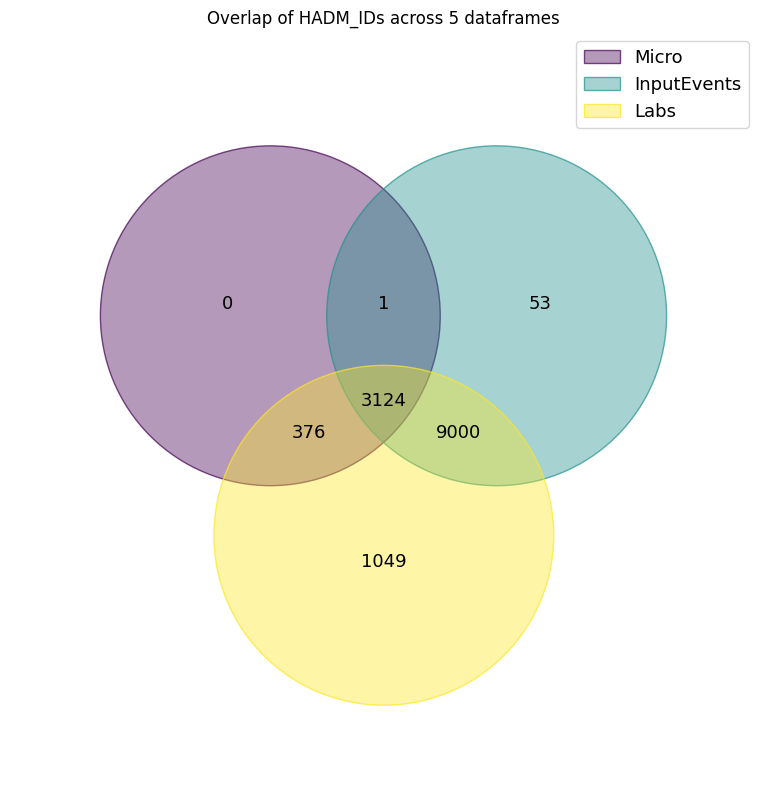

In [35]:


# Ensure the five sets exist
required_sets = {
    'Micro': 'overall_ast_ids',    
    'InputEvents': 'overall_input_ids',
    'Labs': 'overall_lab_ids',
}
missing = [name for name, var in required_sets.items() if var not in globals()]
if missing:
    raise NameError(f"Missing variables for sets: {missing}. Ensure overall_* sets are defined above.")

set_map = {
    'Micro': overall_ast_ids,
    'InputEvents': overall_input_ids,
    'Labs': overall_lab_ids,
}

print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()

# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

{'Micro': 12150, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

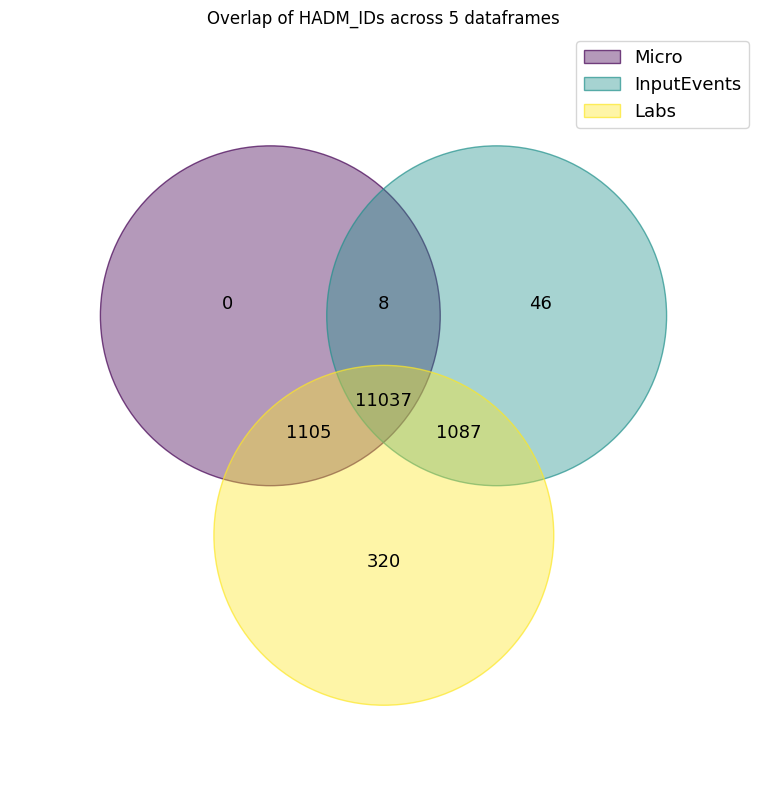

In [32]:


# Ensure the five sets exist
required_sets = {
    'Micro': 'overall_micro_ids',    
    'InputEvents': 'overall_input_ids',
    'Labs': 'overall_lab_ids',
}
missing = [name for name, var in required_sets.items() if var not in globals()]
if missing:
    raise NameError(f"Missing variables for sets: {missing}. Ensure overall_* sets are defined above.")

set_map = {
    'Micro': overall_micro_ids,
    'InputEvents': overall_input_ids,
    'Labs': overall_lab_ids,
}

print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()

# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

{'Micro': 12150, 'Prescriptions': 13568, 'EMAR': 7447, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

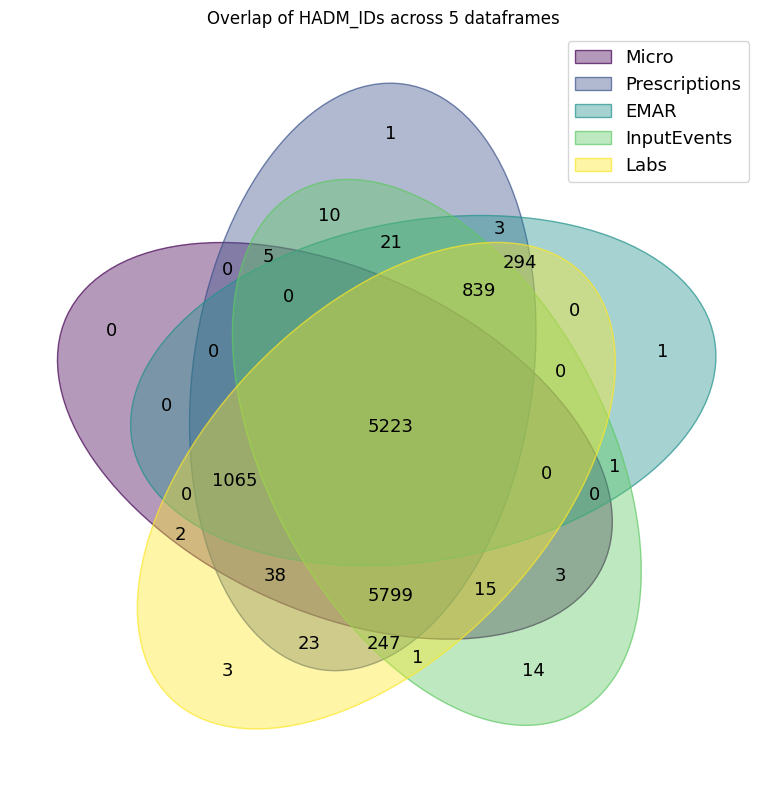

In [28]:


# Ensure the five sets exist
required_sets = {
    'Micro': 'overall_micro_ids',
    'Prescriptions': 'overall_pres_ids',
    'EMAR': 'overall_emar_ids',
    'InputEvents': 'overall_input_ids',
    'Labs': 'overall_lab_ids',
}
missing = [name for name, var in required_sets.items() if var not in globals()]
if missing:
    raise NameError(f"Missing variables for sets: {missing}. Ensure overall_* sets are defined above.")

set_map = {
    'Micro': overall_micro_ids,
    'Prescriptions': overall_pres_ids,
    'EMAR': overall_emar_ids,
    'InputEvents': overall_input_ids,
    'Labs': overall_lab_ids,
}

print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()

# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

{'AST': 3501, 'Prescriptions': 13568, 'EMAR': 7447, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

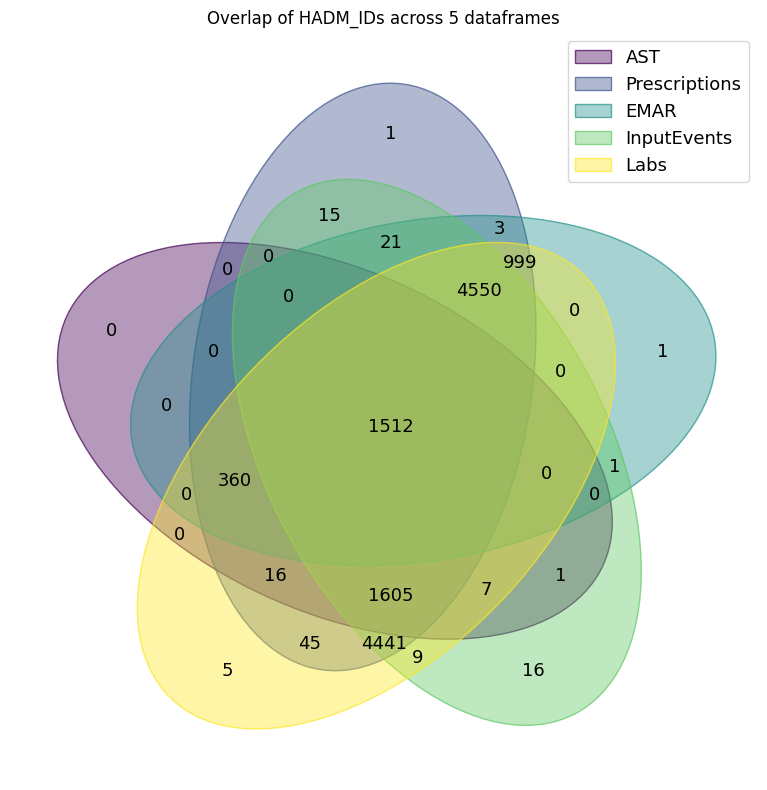

In [29]:
# Ensure the five sets exist
required_sets = {
    'AST': 'overall_ast_ids',
    'Prescriptions': 'overall_pres_ids',
    'EMAR': 'overall_emar_ids',
    'InputEvents': 'overall_input_ids',
    'Labs': 'overall_lab_ids',
}
missing = [name for name, var in required_sets.items() if var not in globals()]
if missing:
    raise NameError(f"Missing variables for sets: {missing}. Ensure overall_* sets are defined above.")

set_map = {
    'AST': overall_ast_ids,
    'Prescriptions': overall_pres_ids,
    'EMAR': overall_emar_ids,
    'InputEvents': overall_input_ids,
    'Labs': overall_lab_ids,
}

print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()

In [ ]:
lab_test_hosp_icu_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dxx(lab_test_hosp_icu_df)
resp_micro_hosp_icu_inf_df=hh.load_data('./parq/resp_micro_hosp_icu_inf_df_23Jan26_2050.parquet')
hh.dxx(resp_micro_hosp_icu_inf_df)